# Planpraz (Chamonix-Mont-Blanc)

## Chargement des librairies

In [1]:
import os
import sys

import matplotlib.pyplot as plt

# Ajout dans la variable PATH du système du chemin où est installée la librairie tracklib
module_path = os.path.abspath(os.path.join('../../../../tracklib'))
if module_path not in sys.path:
    sys.path.append(module_path)
# Alias pour tracklib
import tracklib as tkl

# Ajout dans la variable PATH du système du chemin où est installée la librairie footprint2graph
module_path = os.path.abspath(os.path.join('../../..'))
if module_path not in sys.path:
    sys.path.append(module_path)

In [2]:
import matplotlib.pyplot as plt
import os
import time

from footprint2graph import run_iteration
from footprint2graph import read_config

from footprint2graph.util.Outdoorvision import load_raw_tracks_split

## Chargement des paramètres

In [3]:
print ('!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!')
print ('`````````````````````````````````````````````````````````````````````')
print ('             Generate a footprint graph                              ')
print ('                      from hiking trajectories                       ')
print ('                      in the Planpraz, summer 2024.                  ')
print ('’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’')
print ('!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!')
print ('')


""" ======================================================================= """
"""     Load parameters                                                     """
"""                                                                         """

config_path = r'/home/md_vandamme/7_LIB/footprint2graph/data/config_planpraz.yml'
config = read_config(config_path)


print('Paramètres relevés dans la configuration: ')
print ('Résultats enregistrés dans le répertoire: ', config['output']['RESULT_PATH'])

NBITER = int(config['graph_construction']['NUM_ITERATIONS'])
print ('Number of iterations: ', NBITER)

!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
`````````````````````````````````````````````````````````````````````
             Generate a footprint graph                              
                      from hiking trajectories                       
                      in the Planpraz, summer 2024.                  
’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

Paramètres relevés dans la configuration: 
Résultats enregistrés dans le répertoire:  /home/md_vandamme/4_RESEAU/ZTEMPZ2/
Number of iterations:  2


## Chargement des données

Les données proviennent de la plateforme Outdoorvision. Après avoir été formatées au format CSV, elles sont chargées dans une collection qui servira d’entrée au pipeline.

In [4]:
""" ======================================================================= """
"""     Chargement de la collection de traces                               """
"""                                                                         """

# chemin où sont stockés les traces Outdoorvision:
tracespathsource = r'/home/md_vandamme/5_GPS/OV/CHAM/walk/'

# Paramètre : Coordonnées de la zone d'étude sur laquelle on construit le réseau
#                           Polygone sous la forme d'un tableau de X et de Y
# traces de la zone 1 (3km x 3km)
X = [996920, 998373, 999071, 999347, 998623, 997890, 996638, 996920]
Y = [6542674, 6542770, 6543183, 6543820, 6544857, 6544992, 6544973, 6542674]

fmt = tkl.TrackFormat({'ext': 'CSV',
                       'srid': 'ENU',
                       'id_E': 1, 'id_N': 0, 'id_U': 3, 'id_T': 2,
                       'time_fmt': '2D/2M/4Y 2h:2m:2s',
                       'separator': ';',
                       'header': 0,
                       'cmt': '#',
                       'read_all': True})
collection = load_raw_tracks_split(config['output']['RESULT_PATH'],
                                   tracespathsource, fmt, X, Y)


Loading and split outdoorvision track data...
Reading track data...
     Number files to load:  21211
Starting split ...
     500 / 21211
     1000 / 21211
     1500 / 21211
     2000 / 21211
     2500 / 21211
     3000 / 21211
     3500 / 21211
     4000 / 21211
     4500 / 21211
     5000 / 21211
     5500 / 21211
     6000 / 21211
     6500 / 21211
     7000 / 21211
     7500 / 21211
     8000 / 21211
     8500 / 21211
     9000 / 21211
     9500 / 21211
     10000 / 21211
     10500 / 21211
     11000 / 21211
     11500 / 21211
     12000 / 21211
     12500 / 21211
     13000 / 21211
     13500 / 21211
     14000 / 21211
     14500 / 21211
     15000 / 21211
     15500 / 21211
     16000 / 21211
     16500 / 21211
     17000 / 21211
     17500 / 21211
     18000 / 21211
     18500 / 21211
     19000 / 21211
     19500 / 21211
     20000 / 21211
     20500 / 21211
     21000 / 21211
     Number of tracks after split: 1451


## Lancement du pipeline

In [5]:
# =====================================================================
#    Appel des pipelines pour le nombre d'itérations nécessaires
#

for idx in range(0, NBITER):
    iteration_index = int(idx) + 1

    # run pipeline for the ith iteration
    run_iteration(iteration_index, config, collection)

print ('!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!')
print ('`````````````````````````````````````````````````````````````````````')
print ('                           FIN                                       ')
print ('’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’')
print ('!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!')

-----------------------------------------------------------------
-----------------------------------------------------------------
              ITERATION  1
-----------------------------------------------------------------
-----------------------------------------------------------------
Starting segmentation and resampling...
Starting segmentation ...
     500 / 1451
     1000 / 1451
    Number of tracks after segmentation: 2015
Finished saving segmented tracks.
Starting resampling ...
    Number of tracks to resample:  2015
    Number of tracks after resampling: 2015
    Number of tracks after resampling: 2015
Finished saving resampled tracks.
Stage 1 finished: segmentation and resampling.
Starting rasterization and vectorization (iteration 1) 

    Loading tracks from :  resample_grid
    Number of tracks to load:  2015
    Building high-resolution geometry density grid G1 :  2 m ...
    Building low-resolution contextual density grid G2 :  30 m ...
    Assigning track points to t

100% (483 of 483) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (2617 of 2617) |####################| Elapsed Time: 0:00:00 Time:  0:00:00


    Execution time (seconds): 2.2707924842834473
    Road surface smoothing completed.
    Starting centerline computation ...


100% (398 of 398) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (467 of 467) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (1055 of 1055) |####################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (927 of 927) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (1079 of 1079) |####################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (1010 of 1010) |####################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (1013 of 1013) |####################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (422 of 422) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (619 of 619) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (585 of 585) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (493 of 493) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (9 of 9) |##########################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (506 of 506) |#####################

    Execution time (seconds): 3.4580135345458984
    Centerline computed.
Stage 2 completed: rasterization and vectorization.
Starting topology creation for the network
    Number of edges in the skeleton: 7931
    Finished loaded skeleton.
    /home/md_vandamme/4_RESEAU/ZTEMPZ2/network/tmp_in.csv not exists
    /home/md_vandamme/4_RESEAU/ZTEMPZ2/network/tmp_out.csv not exists


...

    Finished simplification of the skeleton.
Building [100 x 92] spatial index...
    on coupe la trace 1
    on coupe la trace 2
    Number of edges in the skeleton (after snapping): 152
    Edge count difference after snapping :  2
    Number of edges in the simplified skeleton: 126
    Number of nodes: 171
     Shortest edges limit :  50
    Number of edges in the skeleton (after removing the shortest edges): 5
    Conflation cannot be performed for node  50 ; the three incident edges are too long: 31 24 25
    Conflation cannot be performed for node  53 ; the three incident edges are too long: 96 85 37
    Conflation cannot be performed for node  172 ; the three incident edges are too long: 11 36 56
    Conflation cannot be performed for node  174 ; the three incident edges are too long: 11 51 56
    Conflation cannot be performed for node  184 ; the three incident edges are too long: 40 664 411
    Edge count after conflation: 53
Stage 3 completed: adding topology to the skeleton.

100% (93 of 93) |########################| Elapsed Time: 0:00:00 Time:  0:00:00


        Number of tracks: 5720
        Execution time (seconds): 9.888888359069824
    Starting map-matching ...
        Index spatial :  [100 x 91] spatial index centered on [998107.2968269091; 6543843.350262897]
Map-matching preparation...
        Parameter search_radius:  25
        Map-matching ended.
        Execution time (seconds): 268.4186022281647
        Prepare map-matching results for candidate segment generation
    Number of map-matched points = 650800 (84.61 %)
    Map-matching results restructuring completed.
        Map-matching results exported.
Starting construction of candidate trajectory segments for each topology edge ...
    145  candidates for edge 25
    30  candidates for edge 195
    10  candidates for edge 196
    5  candidates for edge 205
    192  candidates for edge 206
    49  candidates for edge 176
    29  candidates for edge 148
    40  candidates for edge 149
    54  candidates for edge 150
    0  candidates for edge 165
    1  candidates for edge 20

100% (119 of 119) |######################| Elapsed Time: 0:00:00 Time:  0:00:00


Size of collection In  :  67
Size of collection In+1:  52
Size of collection In+In+1:  119
Building [100 x 88] spatial index...
Size of collection In+In+1 avec intersection:  123
        Candidate edge ignored (no intersection)
Size of collection In+In+1 avec intersection et raccordement:  171
Nombre de géométries :  171
Size of reseau de mobilité:  171
End building the mobility network.
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
`````````````````````````````````````````````````````````````````````
                           FIN                                       
’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!


## On affiche le résultat

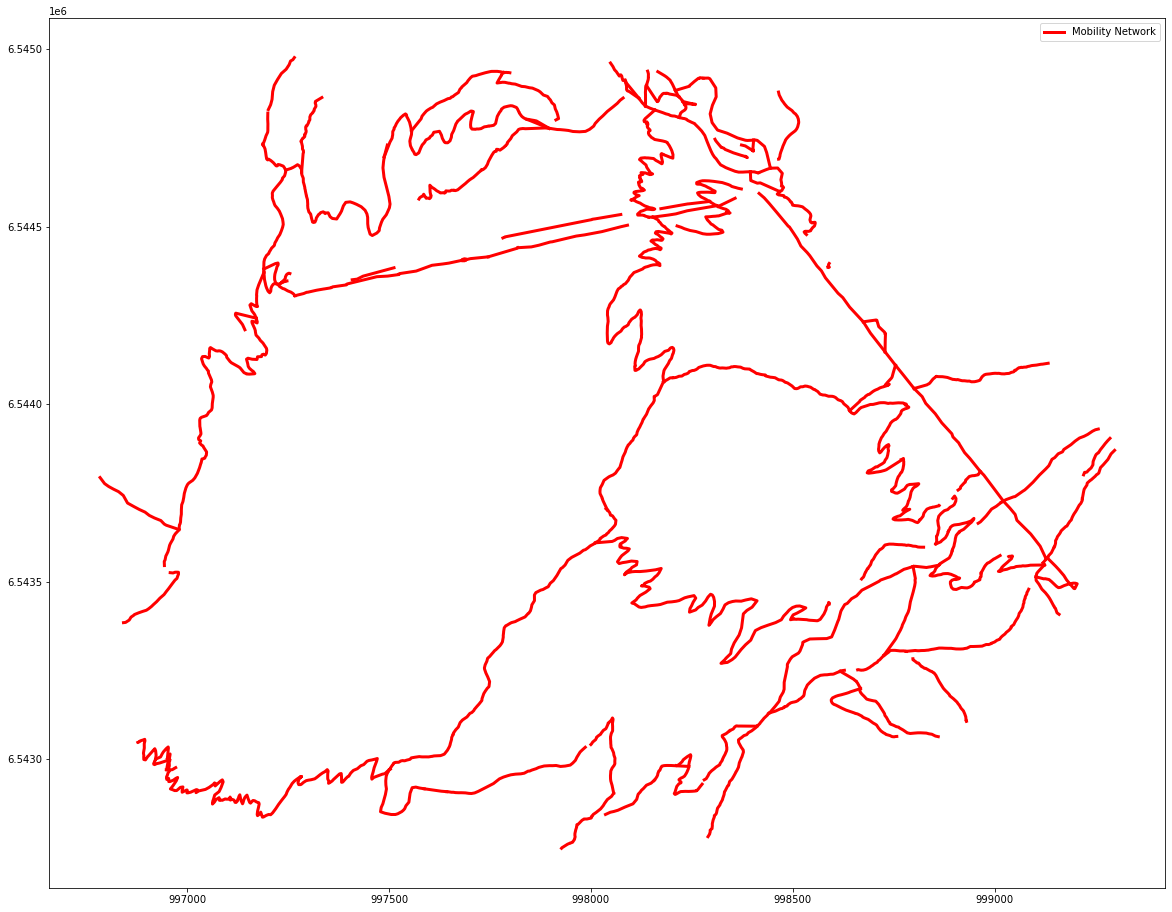

In [6]:
fig, ax = plt.subplots(figsize=(20, 16))

fmt = tkl.NetworkFormat({
           "pos_edge_id": 0,
           "pos_source": 1,
           "pos_target": 2,
           "pos_wkt": 4,
           "srid": "ENU",
           "separator": ",",
           "header": 1})
networkpath = config['output']['RESULT_PATH'] + 'merge_2/reseau_mobilite_2.csv'
squelette = tkl.NetworkReader.readFromFile(networkpath, fmt, verbose=False)

L = list(squelette.EDGES.items())
for i in range(len(L)):
    x1d = []
    y1d = []
    edge = L[i][1]
    for j in range(edge.geom.size()):
        x1d.append(edge.geom.getX()[j])
        y1d.append(edge.geom.getY()[j])
    ax.plot(x1d, y1d, 'r-', linewidth=3, label='Mobility Network')


# Supprime les doublons dans la légende
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys())